# Experiment 8: VG-SAE Sparsity Sweep on Synthetic Sparse Coding

Goal: isolate VG-SAE and sweep the paper-aligned nonnegative sparsity field `gamma`. This is the notebook to use when the question is not "which baseline wins?" but "how do VG-SAE reconstruction, support density, Bernoulli uncertainty, and dictionary recovery change as sparsity pressure increases?"

The sweep uses `gamma >= 0` because the VG prior is `P(s_j) proportional to exp(-gamma s_j)`. Negative values favor dense supports and do not have the sparsity-field meaning used in the paper.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebooks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
from types import SimpleNamespace

from src.sae_data import SyntheticSparseCodingConfig, make_synthetic_sparse_coding
from src.sae_evaluate import (
    amplitude_shrinkage,
    decoder_recovery_cosine,
    support_precision_recall,
    susceptibility,
    vg_sae_observables,
)
from src.sae_model import VGSAEConfig, VariationalGarroteSAE
from src.sae_train import fit_sae
from src.utils import set_seed


## Configuration

Set `VGSAE_NOTEBOOK_FAST_DEV_RUN=1` for a quick smoke run. For paper figures, increase `seeds`, `train_steps`, and the gamma grid.


In [3]:
FAST_DEV_RUN = bool(int(os.environ.get("VGSAE_NOTEBOOK_FAST_DEV_RUN", "0")))

input_dim = 16
n_features = 32
support_density = 0.06
coherence = 0.1
noise_std = 0.03
frequency_skew = 0.0
amplitude_scale = 1.0

if FAST_DEV_RUN:
    seeds = [0]
    n_train = 96
    n_test = 96
    train_steps = 4
    history_every = 1
    gamma_values = [0.0, 1.0]
else:
    seeds = [0, 1, 2]
    n_train = 1024
    n_test = 1024
    train_steps = 800
    history_every = 50
    gamma_values = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0, 10.0]

batch_size = 128
lr = 3.0e-3
beta = 1.0
gradient_clip_norm = 1.0
EXP_DIR = OUTPUT_DIR / "exp08_synthetic_sparse_coding_vg_sparsity_sweep"
EXP_DIR.mkdir(parents=True, exist_ok=True)


In [4]:
def split_sparse_coding_data(data, n_train):
    train = SimpleNamespace(
        x=data.x[:n_train],
        z=data.z[:n_train],
        support=data.support[:n_train],
        dictionary=data.dictionary,
        clean_x=data.clean_x[:n_train],
        feature_probabilities=data.feature_probabilities,
    )
    test = SimpleNamespace(
        x=data.x[n_train:],
        z=data.z[n_train:],
        support=data.support[n_train:],
        dictionary=data.dictionary,
        clean_x=data.clean_x[n_train:],
        feature_probabilities=data.feature_probabilities,
    )
    return train, test


def make_train_test(seed):
    data = make_synthetic_sparse_coding(
        SyntheticSparseCodingConfig(
            input_dim=input_dim,
            n_features=n_features,
            n_samples=n_train + n_test,
            support_density=support_density,
            coherence=coherence,
            noise_std=noise_std,
            frequency_skew=frequency_skew,
            amplitude_scale=amplitude_scale,
            seed=seed,
        ),
        device=DEVICE,
    )
    return split_sparse_coding_data(data, n_train)


train0, test0 = make_train_test(seeds[0])
print(
    "train", tuple(train0.x.shape),
    "test", tuple(test0.x.shape),
    "empirical train density", float(train0.support.mean()),
    "empirical test density", float(test0.support.mean()),
)


train (1024, 16) test (1024, 16) empirical train density 0.058258056640625 empirical test density 0.0615234375


## Run Sweep

Decoder atoms are evaluated against the ground-truth dictionary, so support precision and recall are meaningful only after decoder matching.


In [5]:
final_rows = []
history_rows = []

for seed in seeds:
    train_data, test_data = make_train_test(seed)
    for gamma_index, gamma in enumerate(gamma_values):
        run_id = f"vgsae_gamma={gamma}_seed={seed}"
        print("training", run_id)
        init_seed = 100_000 + 1_000 * seed + gamma_index
        set_seed(init_seed)
        model = VariationalGarroteSAE(
            VGSAEConfig(
                input_dim=input_dim,
                n_latents=n_features,
                lambda_sparsity=float(gamma),
                beta=beta,
            )
        )
        result = fit_sae(
            model,
            train_data.x,
            lr=lr,
            batch_size=batch_size,
            max_steps=train_steps,
            gradient_clip_norm=gradient_clip_norm,
            history_every=history_every,
            seed=init_seed,
        )
        obs = vg_sae_observables(model, test_data.x)
        precision, recall = support_precision_recall(
            model,
            test_data.x,
            test_data.support,
            test_data.dictionary,
        )
        final_rows.append({
            "run_id": run_id,
            "seed": seed,
            "gamma": float(gamma),
            "empirical_support_density": float(test_data.support.mean()),
            "reconstruction_mse": obs.mse,
            "rho_model": obs.rho,
            "entropy": obs.entropy,
            "v_eff": obs.v_eff,
            "dead_fraction": obs.dead_fraction,
            "interference_energy": obs.interference_energy,
            "variance_energy": obs.variance_energy,
            "decoder_recovery_cosine": decoder_recovery_cosine(model.decoder.weight, test_data.dictionary),
            "support_precision": precision,
            "support_recall": recall,
            "amplitude_shrinkage": amplitude_shrinkage(
                model,
                test_data.x,
                test_data.z,
                test_data.dictionary,
            ),
        })
        for hrow in result.history:
            history_rows.append({"run_id": run_id, "seed": seed, "gamma": float(gamma), **hrow})

final_df = pd.DataFrame(final_rows).sort_values(["seed", "gamma"]).reset_index(drop=True)
history_df = pd.DataFrame(history_rows)
for seed, sub in final_df.groupby("seed"):
    idx = sub.index
    final_df.loc[idx, "susceptibility"] = susceptibility(
        sub["gamma"].to_numpy(dtype=float),
        sub["rho_model"].to_numpy(dtype=float),
    )
final_df


training vgsae_gamma=0.0_seed=0
training vgsae_gamma=0.25_seed=0
training vgsae_gamma=0.5_seed=0
training vgsae_gamma=1.0_seed=0
training vgsae_gamma=1.5_seed=0
training vgsae_gamma=2.0_seed=0
training vgsae_gamma=3.0_seed=0
training vgsae_gamma=5.0_seed=0
training vgsae_gamma=7.0_seed=0
training vgsae_gamma=10.0_seed=0
training vgsae_gamma=0.0_seed=1
training vgsae_gamma=0.25_seed=1
training vgsae_gamma=0.5_seed=1
training vgsae_gamma=1.0_seed=1
training vgsae_gamma=1.5_seed=1
training vgsae_gamma=2.0_seed=1
training vgsae_gamma=3.0_seed=1
training vgsae_gamma=5.0_seed=1
training vgsae_gamma=7.0_seed=1
training vgsae_gamma=10.0_seed=1
training vgsae_gamma=0.0_seed=2
training vgsae_gamma=0.25_seed=2
training vgsae_gamma=0.5_seed=2
training vgsae_gamma=1.0_seed=2
training vgsae_gamma=1.5_seed=2
training vgsae_gamma=2.0_seed=2
training vgsae_gamma=3.0_seed=2
training vgsae_gamma=5.0_seed=2
training vgsae_gamma=7.0_seed=2
training vgsae_gamma=10.0_seed=2


,run_id,seed,gamma,empirical_support_density,reconstruction_mse,rho_model,entropy,v_eff,dead_fraction,interference_energy,variance_energy,decoder_recovery_cosine,support_precision,support_recall,amplitude_shrinkage,susceptibility
0,vgsae_gamma=0.0_seed=0,0,0.00,0.061523,0.025488,0.629048,0.539940,0.188124,0.0,0.655151,0.069345,0.676937,0.072467,0.914683,1.211132,0.411080
1,vgsae_gamma=0.25_seed=0,0,0.25,0.061523,0.030223,0.526278,0.588685,0.206252,0.0,0.359142,0.083184,0.785355,0.112923,0.817460,1.429287,0.383178
2,vgsae_gamma=0.5_seed=0,0,0.50,0.061523,0.030918,0.437459,0.584413,0.202356,0.0,0.363103,0.128104,0.781008,0.170248,0.723214,0.845006,0.314903
3,vgsae_gamma=1.0_seed=0,0,1.00,0.061523,0.033665,0.320379,0.522964,0.174455,0.0,0.256523,0.128656,0.800209,0.254697,0.591766,0.712132,0.214018
4,vgsae_gamma=1.5_seed=0,0,1.50,0.061523,0.031934,0.223442,0.422078,0.132220,0.0,0.199407,0.120297,0.839188,0.338651,0.505456,0.556996,0.161131
5,vgsae_gamma=2.0_seed=0,0,2.00,0.061523,0.030418,0.159248,0.322503,0.094524,0.0,0.195548,0.126106,0.873464,0.390297,0.442956,0.518165,0.105162
6,vgsae_gamma=3.0_seed=0,0,3.00,0.061523,0.035085,0.100538,0.225939,0.060986,0.0,0.119185,0.119185,0.878697,0.508651,0.364583,0.425765,0.047146
7,vgsae_gamma=5.0_seed=0,0,5.00,0.061523,0.074299,0.052500,0.135631,0.033055,0.0,0.066236,0.139780,0.764275,0.536328,0.201389,0.262693,0.021006
8,vgsae_gamma=7.0_seed=0,0,7.00,0.061523,0.186388,0.016513,0.059587,0.012381,0.0,0.018256,0.102322,0.653144,0.740000,0.055060,0.122431,0.012022
9,vgsae_gamma=10.0_seed=0,0,10.00,0.061523,0.242681,0.007318,0.031441,0.005947,0.0,0.007494,0.068590,0.506554,0.574468,0.013393,0.033869,0.003065


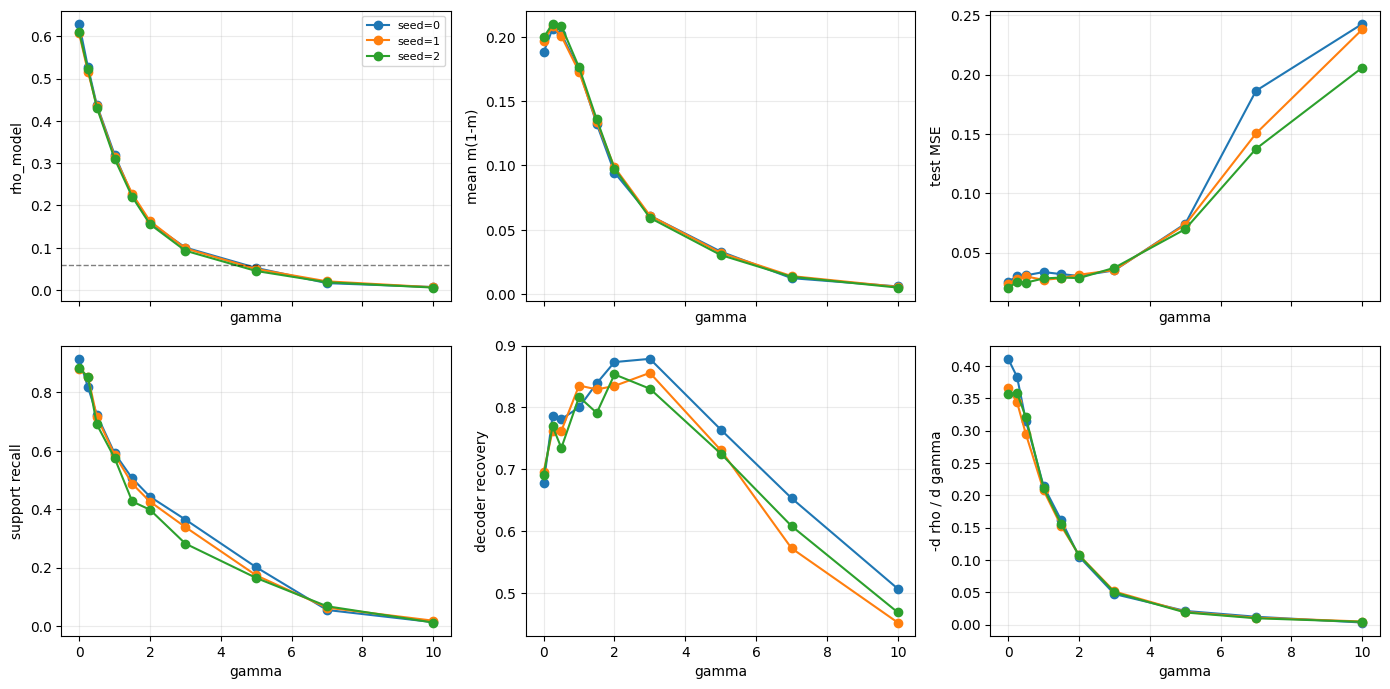

In [6]:
final_df.to_csv(EXP_DIR / "vg_sparsity_sweep.csv", index=False)
history_df.to_csv(EXP_DIR / "vg_sparsity_training_curves.csv", index=False)

metrics = [
    ("rho_model", "rho_model"),
    ("v_eff", "mean m(1-m)"),
    ("reconstruction_mse", "test MSE"),
    ("support_recall", "support recall"),
    ("decoder_recovery_cosine", "decoder recovery"),
    ("susceptibility", "-d rho / d gamma"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, (metric, ylabel) in zip(axes.ravel(), metrics, strict=True):
    for seed, sub in final_df.groupby("seed"):
        sub = sub.sort_values("gamma")
        ax.plot(sub["gamma"], sub[metric], marker="o", linewidth=1.5, label=f"seed={seed}")
    ax.axhline(support_density, color="black", linestyle="--", linewidth=1, alpha=0.5) if metric == "rho_model" else None
    ax.set_xlabel("gamma")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
axes[0, 0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(EXP_DIR / "vg_sparsity_sweep.png", dpi=160)


## Interpretation Checks

- `rho_model` should generally decrease as `gamma` increases. If not, optimization is dominating the prior.
- A useful VG-SAE regime should keep reconstruction error low while moving `rho_model` toward the empirical support density.
- A peak in susceptibility or `v_eff` is a transition diagnostic, not proof that the true number of features has been recovered.
